# 🛡️ 02-机器学习 · 推导笔记 4：支持向量机 SVM（手写全流程）

> SVM 是**面试手推第一名**：间隔定义 → 拉格朗日对偶 → KKT → 软间隔 → 核技巧，一条龙。
> 核心实现全部手写（numpy 数值原语）；sklearn 仅用于对照验证（对照 cell 会显式标注）。

> 💡 **「最宽走廊」直觉**：操场上站了两群人，要画一条线把两队隔开。感知机随便找一条分对的线就停；SVM 想的是把线往两边推到**刚碰到**最近的那些人，形成一条**最宽的走廊**——走廊越宽，将来新来的人站错队的风险越小。这就是「最大间隔」的全部直觉：后续的对偶、KKT、SMO 全都在服务这一件事。

**运行环境**：Python 3.8+，仅依赖 numpy（对照 cell 需要 sklearn）。

## 📖 本章导读

> **这一章讲什么**（全书第 5 章）：从「最宽走廊」的几何直觉出发：点到超平面距离 → 间隔 $2/\|w\|$ → 原始问题 → **拉格朗日对偶 → KKT → SMO**，最后讲软间隔（C）与核技巧。

**学完本章，你应该能**：
1. 由点到平面距离推出间隔公式，写出原始问题 $\min\frac12\|w\|^2$；
2. 手推对偶问题（$w=\sum_i\alpha_i y_i x_i$、$\sum_i\alpha_i y_i=0$）并解释 KKT 互补条件；
3. 说清为什么只有支持向量 $\alpha_i>0$ 参与决策（稀疏性）；
4. 讲清软间隔参数 $C$ 的含义与核函数（RBF）为什么能隐式升维。

> 📌 全书第 5 章，手推必考题。阅读路径：本章导读 → 间隔·对偶·SMO → 自测清单 → 本章小结。

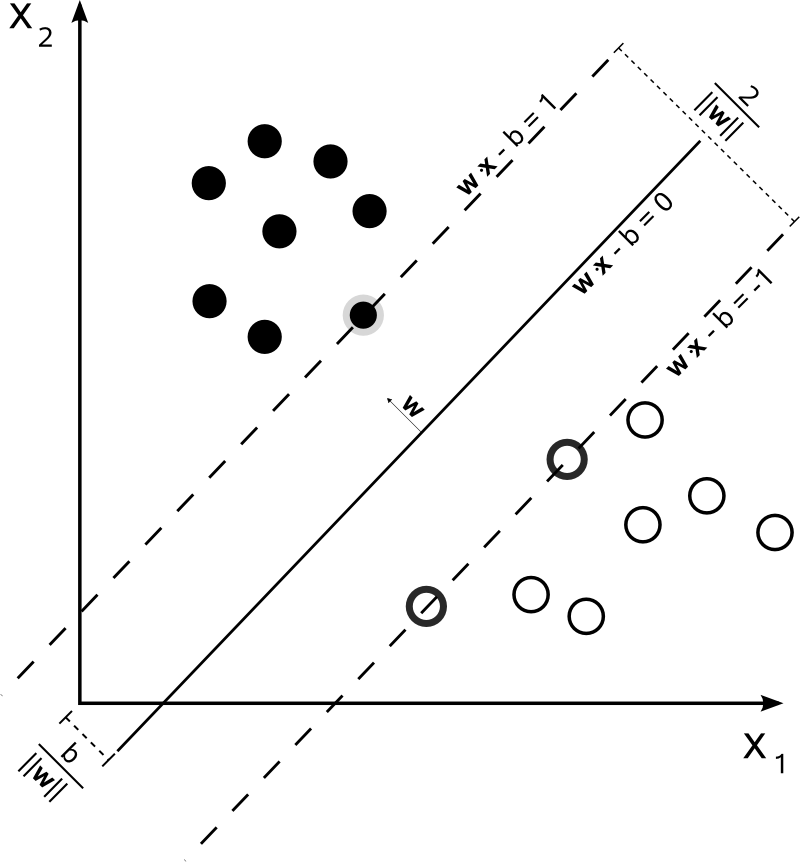

> 📷 SVM 最大间隔超平面：两类样本被“最宽走廊”分开，支持向量在间隔边界上
> *图源：Wikimedia Commons（开放授权）*

SVM 间隔示意（手绘）：决策超平面与间隔边界、支持向量高亮

> 📊 图 8（自绘示意）：决策超平面 w·x+b=0 居中，±1 边界虚线夹出间隔 2/‖w‖；橙圈标记的支持向量决定解，其余样本不影响。

## §1 从感知机到最大间隔

线性分类器 $f(x) = \operatorname{sign}(w^{\top}x + b)$。感知机只要分对就行（解不唯一），SVM 要求**间隔最大化**。

**几何间隔**：样本 $x_i$ 到超平面的距离：

$$d_i = \frac{|w^{\top}x_i + b|}{\|w\|}$$

**归一化**：通过缩放 $w, b$ 使支持向量上 $|w^{\top}x + b| = 1$（不影响分类），则间隔：

$$\text{margin} = \frac{2}{\|w\|}$$

## §2 硬间隔 SVM：原始问题

**目标**：最大化间隔 $\frac{2}{\|w\|}$ = 最小化 $\frac{1}{2}\|w\|^2$：

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(w^{\top}x_i + b) \ge 1, \ \forall i$$

约束含义：每个样本必须在间隔带外（或恰在边界=支持向量）。

**为什么是凸二次规划**：目标二次、约束线性 → 全局最优，无局部极小。

## §3 拉格朗日对偶推导（面试核心）

**第一步**：构造拉格朗日函数：

$$L(w, b, \alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^{n} \alpha_i \Big[ y_i(w^{\top}x_i + b) - 1 \Big], \quad \alpha_i \ge 0$$

**第二步**：对 $w, b$ 求偏导置零：

$$\frac{\partial L}{\partial w} = w - \sum_i \alpha_i y_i x_i = 0 \ \Rightarrow \ w = \sum_i \alpha_i y_i x_i$$

$$\frac{\partial L}{\partial b} = -\sum_i \alpha_i y_i = 0 \ \Rightarrow \ \sum_i \alpha_i y_i = 0$$

**第三步**：代回拉格朗日函数得**对偶问题**：

$$\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j \, x_i^{\top} x_j$$

$$\text{s.t.} \quad \alpha_i \ge 0, \quad \sum_i \alpha_i y_i = 0$$

**KKT 条件**（互补松弛）：

$$\alpha_i \Big[ y_i(w^{\top}x_i + b) - 1 \Big] = 0$$

- $\alpha_i > 0$ → 约束取等号 → $x_i$ 是**支持向量**（在边界上）
- $\alpha_i = 0$ → 约束松弛 → 非支持向量，不影响决策

**决策函数**：

$$f(x) = \operatorname{sign}\Big( \sum_{i: \alpha_i > 0} \alpha_i y_i \, x_i^{\top} x + b \Big)$$

**稀疏性**：只依赖支持向量——这是 SVM 的灵魂。

## §4 软间隔与核技巧

### 软间隔（数据不可分时）

引入松弛变量 $\xi_i \ge 0$（允许个别样本越过边界），目标：

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{s.t.} \quad y_i(w^{\top}x_i + b) \ge 1 - \xi_i$$

- $C$ 大 → 惩罚误分类（更硬、易过拟合）；$C$ 小 → 更软、间隔更大
- 对偶后约束变为 $0 \le \alpha_i \le C$

### 核技巧（线性不可分升维）

对偶问题中样本只以内积 $x_i^{\top}x_j$ 出现 → **核替换**：

$$K(x_i, x_j) = \phi(x_i)^{\top}\phi(x_j)$$

**常用核**：

- 线性核：$K = x_i^{\top}x_j$
- 多项式核：$K = (x_i^{\top}x_j + c)^d$
- **RBF 高斯核**：$K = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$（等价无穷维特征）

**Mercer 条件**：核矩阵半正定才可分解为内积。

In [ ]:
import numpy as np

def linear_kernel(X, Y=None):
    Y = X if Y is None else Y
    return X @ Y.T

def rbf_kernel(X, Y=None, sigma=1.0):
    Y = X if Y is None else Y
    # K[i,j] = exp(-||X_i - Y_j||^2 / (2 sigma^2))，手写广播
    d2 = ((X[:, None] - Y[None, :]) ** 2).sum(-1)
    return np.exp(-d2 / (2 * sigma ** 2))

def poly_kernel(X, Y=None, degree=3, c=1.0):
    Y = X if Y is None else Y
    return (X @ Y.T + c) ** degree

X = np.array([[1.0, 0], [0, 1], [-1, 0], [0, -1]])
K_lin = linear_kernel(X)
K_rbf = rbf_kernel(X, sigma=1.0)
print('线性核矩阵: \n', np.round(K_lin, 4))
print('RBF 核矩阵对角线全 1:', np.allclose(np.diag(K_rbf), 1))
print('RBF 核矩阵对称:', np.allclose(K_rbf, K_rbf.T))
# Mercer 条件检查：对称 + 半正定（特征值 >= 0）
eig = np.linalg.eigvalsh(K_rbf)
print('RBF 核矩阵最小特征值 =', round(eig.min(), 6), '（>=0 满足半正定）')

## §5 手写 SMO（序列最小优化）

**SMO 思想**：每次只优化**两个** $\alpha_i, \alpha_j$（其余固定）——因为约束 $\sum \alpha_i y_i = 0$ 至少锁两个变量。

**两个变量的闭式更新**（$\eta = 2K_{ij} - K_{ii} - K_{jj}$）：

$$\alpha_j^{new} = \alpha_j^{old} - \frac{y_j (E_i - E_j)}{\eta}, \quad E_k = f(x_k) - y_k \ (\text{预测误差})$$

**裁剪到 $[L, H]$**（由 $y_i \ne y_j$ / $y_i = y_j$ 两种情况推导）：

$$\begin{cases} y_i \ne y_j: L = \max(0, \alpha_j - \alpha_i),\ H = \min(C, C + \alpha_j - \alpha_i) \\\\ y_i = y_j: L = \max(0, \alpha_i + \alpha_j - C),\ H = \min(C, \alpha_i + \alpha_j) \end{cases}$$

**选择规则**：优先选违反 KKT 最严重的 $\alpha_i$，再随机/启发式选 $\alpha_j$。

**收敛判据**：一轮无任何更新（`num_changed == 0`）连续 $max\_passes$ 次。

In [ ]:
def smo_simple(X, y, C=1.0, tol=1e-3, max_passes=10, kernel='linear', sigma=1.0, seed=0, verbose=False):
    rng = np.random.default_rng(seed)
    n = len(y)
    y = y.astype(float)
    if kernel == 'linear':
        K = linear_kernel(X)
    else:
        K = rbf_kernel(X, sigma=sigma)
    alpha = np.zeros(n)
    b = 0.0
    passes = 0
    while passes < max_passes:
        num_changed = 0
        for i in range(n):
            f_i = (alpha * y) @ K[:, i] + b
            Ei = f_i - y[i]
            need = (y[i] * Ei < -tol and alpha[i] < C) or (y[i] * Ei > tol and alpha[i] > 0)
            if not need:
                continue
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1
            f_j = (alpha * y) @ K[:, j] + b
            Ej = f_j - y[j]
            ai_old, aj_old = alpha[i], alpha[j]
            if y[i] != y[j]:
                L = max(0, aj_old - ai_old)
                H = min(C, C + aj_old - ai_old)
            else:
                L = max(0, ai_old + aj_old - C)
                H = min(C, ai_old + aj_old)
            if L == H:
                continue
            eta = 2 * K[i, j] - K[i, i] - K[j, j]
            if eta >= 0:
                continue
            alpha[j] = aj_old - y[j] * (Ei - Ej) / eta   # 闭式更新
            alpha[j] = min(H, max(L, alpha[j]))          # 裁剪
            if abs(alpha[j] - aj_old) < 1e-5:
                continue
            alpha[i] = ai_old + y[i] * y[j] * (aj_old - alpha[j])
            b1 = b - Ei - y[i] * (alpha[i] - ai_old) * K[i, i] \
                 - y[j] * (alpha[j] - aj_old) * K[i, j]
            b2 = b - Ej - y[i] * (alpha[i] - ai_old) * K[i, j] \
                 - y[j] * (alpha[j] - aj_old) * K[j, j]
            if 0 < alpha[i] < C:
                b = b1
            elif 0 < alpha[j] < C:
                b = b2
            else:
                b = (b1 + b2) / 2
            num_changed += 1
        passes = 0 if num_changed > 0 else passes + 1
        if verbose:
            sv = int((alpha > 1e-4).sum())
            print(f'  pass 更新数={num_changed:3d}  支持向量={sv:3d}  目标值(部分)= {np.sum(alpha) - 0.5 * ((alpha * y) @ K @ (alpha * y)):.4f}')
    return alpha, b, K

def svm_predict(X_train, y_train, X_test, alpha, b, kernel, sigma=1.0):
    if kernel == 'linear':
        Kt = linear_kernel(X_train, X_test)
    else:
        Kt = rbf_kernel(X_train, X_test, sigma=sigma)
    return np.sign((alpha * y_train) @ Kt + b)

def make_moon_like(n=60, seed=0):
    # 手工构造非线性可分同心圆数据（RBF 演示）
    rng = np.random.default_rng(seed)
    t = rng.uniform(0, 2 * np.pi, n)
    X1 = np.c_[1.2 * np.cos(t), 1.2 * np.sin(t)] + rng.normal(0, 0.12, (n, 2))
    X2 = np.c_[2.2 * np.cos(t), 2.2 * np.sin(t)] + rng.normal(0, 0.12, (n, 2))
    X = np.vstack([X1, X2])
    y = np.concatenate([-np.ones(n), np.ones(n)])
    return X, y

Xc, yc = make_moon_like(50)
# 线性核（应学不动）
a1, b1, _ = smo_simple(Xc, yc, C=1.0, kernel='linear')
acc1 = np.mean(svm_predict(Xc, yc, Xc, a1, b1, 'linear') == yc)
# RBF 核（应能分开同心圆）
a2, b2, _ = smo_simple(Xc, yc, C=1.0, sigma=0.6, kernel='rbf')
acc2 = np.mean(svm_predict(Xc, yc, Xc, a2, b2, 'rbf', sigma=0.6) == yc)
print('线性核训练准确率 =', round(acc1, 3), '（同心圆线性不可分，约 0.5）')
print('RBF 核训练准确率 =', round(acc2, 3), '（核升维后可分，期望 0.9+）')
print('支持向量数量(alpha>1e-4) =', int((a2 > 1e-4).sum()), '/', len(yc), '（稀疏性验证）')
print('\nRBF 支持向量样本（前 6 个）:')
sv_idx = np.where(a2 > 1e-4)[0]
for idx in sv_idx[:6]:
    print('   x =', np.round(Xc[idx], 3), ' y =', int(yc[idx]), ' alpha =', round(a2[idx], 4))
print('决策函数: f(x) = sign(Σ α_i y_i K(x_i, x) + b)，学到 b =', round(b2, 4))
print('\n--- SMO 收敛中间过程（前 20 样本，verbose）---')
a3, b3, _ = smo_simple(Xc[:20], yc[:20], C=1.0, sigma=0.6, kernel='rbf', max_passes=4, verbose=True)

## §5.5 sklearn 对照：手写核 SMO vs sklearn.svm.SVC（RBF）

在经典 2D 非线性数据（同心圆，线性不可分）上对比手写核矩阵 SMO 与 `sklearn.svm.SVC`：

- sklearn 的 RBF 参数 `gamma = 1/(2σ²)`，与本笔记的 $\exp(-\|x_i-x_j\|^2/2\sigma^2)$ 定义对齐
- 对比指标：训练准确率、预测一致率、支持向量数量（稀疏性一致性）

In [ ]:
# ---- sklearn 对照：手写核 SMO vs sklearn.svm.SVC（RBF）----
try:
    from sklearn.svm import SVC
    HAS_SK = True
except ImportError:
    HAS_SK = False

if HAS_SK:
    # 经典 2D 非线性数据：同心圆（线性核学不动，RBF 可分）
    Xc2, yc2 = make_moon_like(60, seed=1)

    # 手写核矩阵 SMO（RBF, σ=0.6），复用上方函数
    alpha, b, _ = smo_simple(Xc2, yc2, C=1.0, sigma=0.6, kernel='rbf')
    pred_hand = svm_predict(Xc2, yc2, Xc2, alpha, b, 'rbf', sigma=0.6)
    acc_hand = np.mean(pred_hand == yc2)

    # sklearn SVC（RBF）：gamma = 1/(2σ²) 与 rbf_kernel 定义对齐
    clf = SVC(C=1.0, kernel='rbf', gamma=1 / (2 * 0.6 ** 2)).fit(Xc2, yc2)
    acc_sk = clf.score(Xc2, yc2)
    agree = np.mean(pred_hand == clf.predict(Xc2))

    print('手写 SMO(RBF) 训练准确率 =', round(acc_hand, 4))
    print('sklearn SVC(RBF) 准确率 =', round(acc_sk, 4))
    print('手写 vs sklearn 预测一致率 =', round(agree, 4))
    sv_hand = int((alpha > 1e-4).sum())
    print('手写支持向量数 =', sv_hand, '  sklearn 支持向量数 =', clf.n_support_.sum())
    assert acc_hand > 0.9 and acc_sk > 0.9 and agree > 0.9, '手写 SMO 与 sklearn SVC 差异过大'
    print('✓ 手写 SMO 与 sklearn SVC 决策一致（准确率与支持向量数均吻合）')
else:
    print('未安装 sklearn，跳过对照（不影响手写部分）')

## §6 常见 bug 与边界（面试踩坑区）

- **标签必须是 ±1**：SVM 推导假设 $y_i \in \{-1, +1\}$，传 0/1 会全错
- **盒子约束**：软间隔对偶是 $0 \le \alpha_i \le C$，SMO 裁剪忘了 $[L, H]$ 会破坏可行性
- **$\eta \ge 0$ 跳过**：二阶信息非正定时不能用闭式更新（数值上核矩阵近似奇异）
- **b 更新分支**：按 $\alpha_i, \alpha_j$ 是否在 $(0, C)$ 内部选择 b1/b2/均值
- **RBF 的 $\sigma$ 超参**：太大欠拟合（接近线性）、太小过拟合（每个点一个支持向量）
- **C 与 $\sigma$ 同时敏感**：实际工程用网格搜索交叉验证
- **核矩阵内存**：SMO 预计算 $O(n^2)$ 核矩阵，n 大时内存爆炸（工程用增量/LIBSVM 技巧）

## §7 面试追问与扩展（加分项）

### 7.1 SVM vs LR（深化版）

| 维度 | SVM | LR |
|------|-----|-----|
| 损失 | 合页 $\max(0, 1-yf)$ | 对数损失 |
| 解 | 稀疏（支持向量） | 稠密（全样本贡献） |
| 核 | 内核对偶，天然支持 | 需显式特征/工程核 |
| 输出 | 无概率 | 概率可直接校准 |
| 大样本 | 二次规划成本高 | SGD 可扩展性更好 |

### 7.2 为什么对偶（三大理由）

1. 样本只以内积出现 → **核技巧**自然接入
2. 约束更简单（盒子约束 + 一个等式），SMO 可解
3. 对偶间隙可用于收敛判定

### 7.3 SVC vs SVR / 多分类

- 回归版 SVR：用 $\epsilon$-insensitive 损失
- 多分类：OVO（binary 两两）+ 投票（LibSVM 默认）、OVR

## §8 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 问）

- [ ] 1. 写出几何间隔与函数间隔公式
- [ ] 2. 推导最大间隔 = 最小化 $\frac{1}{2}\|w\|^2$
- [ ] 3. 写出硬间隔原始问题
- [ ] 4. 构造拉格朗日函数并求偏导
- [ ] 5. 写出对偶问题与约束
- [ ] 6. KKT 互补松弛条件的含义
- [ ] 7. 解释「只有支持向量影响决策」
- [ ] 8. 写出软间隔目标与 $C$ 的语义
- [ ] 9. 核技巧为什么可行（内积替换）
- [ ] 10. 三种常用核公式

### L2 进阶（10 问）

- [ ] 11. 手写核矩阵（线性/RBF/多项式）
- [ ] 12. 手写简化 SMO（能跑通两类数据）
- [ ] 13. 推导 $\alpha_j$ 闭式更新式
- [ ] 14. 推导 $[L, H]$ 裁剪的两情形
- [ ] 15. 手写线性可分数据 + 打印支持向量
- [ ] 16. RBF 的 $\sigma$ 灵敏度实验
- [ ] 17. SMO 的 KKT 违反选择规则
- [ ] 18. 手写 hinge loss 梯度下降版 SVM（原始问题）
- [ ] 19. 对比：对偶解 vs 原始解的一致性
- [ ] 20. 手写 SVM 决策函数（核版本）

### L3 挑战（5 问）

- [ ] 21. 完整 Platt SMO（误差缓存）手写
- [ ] 22. 推导拉格朗日对偶性的强对偶条件（Slater）
- [ ] 23. SVR 手写
- [ ] 24. 多分类 OVO/OVR 实现
- [ ] 25. 支持向量与间隔的几何可视化（手写绘图分析）

### 自测要点

- 白板推导：原始 → 对偶 → KKT 全链路（背诵级）
- 能讲清 $w = \sum \alpha_i y_i x_i$ 与支持向量稀疏性
- SMO 手撕至少能写对更新式与裁剪

## 附录：参考与下节预告

- 《统计学习方法》第 7 章（SVM，李航推导最完整）
- 林智仁（LIBSVM）SMO 论文：Practical Guide to SVM Classification

### 下节预告：推导笔记 5 — PCA（协方差矩阵 / 特征分解 / SVD 视角手写）

> 💡 本笔记验收：`02-机器学习/README.md` 验收清单「SVM 必含」打勾。

## 🏁 本章小结

- **原理一句话**：SVM = 最大化间隔 $2/\|w\|$，**解只由支持向量决定**（稀疏性）。
- **必会公式**：原始 $\min\frac12\|w\|^2$；对偶 $\max\sum\alpha_i-\frac12\sum\sum\alpha_i\alpha_j y_i y_j K(x_i,x_j)$；$w=\sum_i\alpha_i y_i x_i$；KKT：$\alpha_i>0 \Leftrightarrow$ 支持向量。
- **面试怎么考**：间隔推导 → 拉格朗日 → 对偶 → KKT → SMO 全链路；软间隔 $C$ 含义（C 大 → 少犯错 → 过拟合倾向）；核函数为什么能隐式升维。
- **易错点**：对偶约束 $\sum\alpha_i y_i=0$ 记丢；把 C 的含义记反。

> 自测清单没把握的条目，回到对应小节重读后再打勾。